In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('/content/Cardataset.csv')

cols_to_clean = [
    'total_mass_kg', 'tire_pressure_psi', 'drag_coefficient',
    'horsepower', 'frontal_area_m2', 'est_km_per_l',
    'displacement_cc', 'mag_weight_kg'
]
for col in cols_to_clean:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].str.replace(r'\(est\)', '', regex=True).str.strip().astype(float)

print(f"Dataset loaded: {len(df)} rows, {len(df.columns)} columns")
print(df.head())

Dataset loaded: 100 rows, 13 columns
                        Model  total_mass_kg  mag_size_inch  mag_weight_kg  \
0  Toyota Hilux Revo (2.8 GD)           1850             18           12.0   
1       Isuzu D-Max (1.9 Ddi)           1750             16            9.0   
2     Toyota Yaris ATIV (1.2)           1200             15            8.0   
3    Toyota Yaris Cross (1.5)           1200             15            8.0   
4      Honda City (1.5 Turbo)           1200             17           10.5   

   tire_width_mm  tire_pressure_psi  drag_coefficient  frontal_area_m2  \
0            265                 36              0.40              2.8   
1            245                 36              0.40              2.8   
2            205                 32              0.29              2.0   
3            205                 32              0.29              2.0   
4            185                 32              0.29              2.0   

   horsepower  displacement_cc  fuel_type  env_te

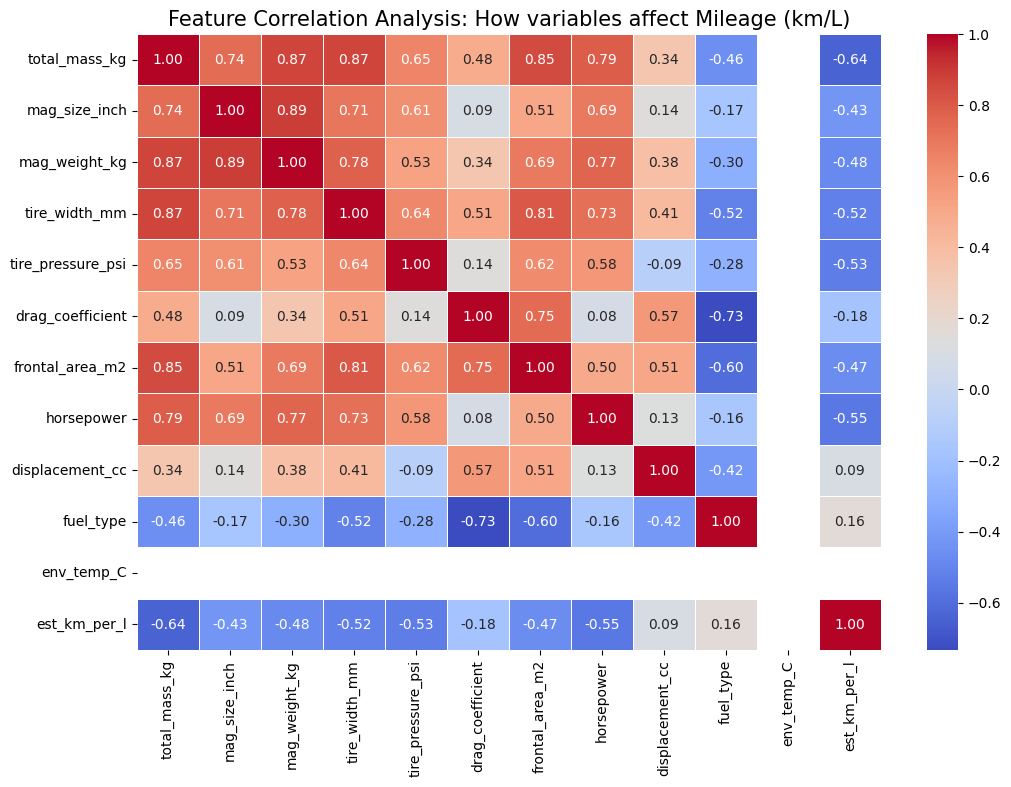


Dataset Summary:
       total_mass_kg  horsepower  tire_pressure_psi  est_km_per_l
count         100.00      100.00             100.00        100.00
mean         1560.45      169.05              33.92         14.26
std           355.83       57.44               2.08          4.21
min           950.00       83.00              30.00          7.50
25%          1272.50      130.00              32.00         12.00
50%          1500.00      159.00              34.00         13.00
75%          1770.00      190.00              36.00         16.00
max          2500.00      397.00              42.00         27.00


In [ ]:
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Analysis: How variables affect Mileage (km/L)', fontsize=15)
plt.show()
print("\nDataset Summary:")
summary = df[['total_mass_kg', 'horsepower', 'tire_pressure_psi', 'est_km_per_l']].describe().round(2)
print(summary)

In [ ]:
X = df[['total_mass_kg', 'horsepower', 'displacement_cc', 'tire_pressure_psi']]
y = df['est_km_per_l']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

Train: 80 rows | Test: 20 rows


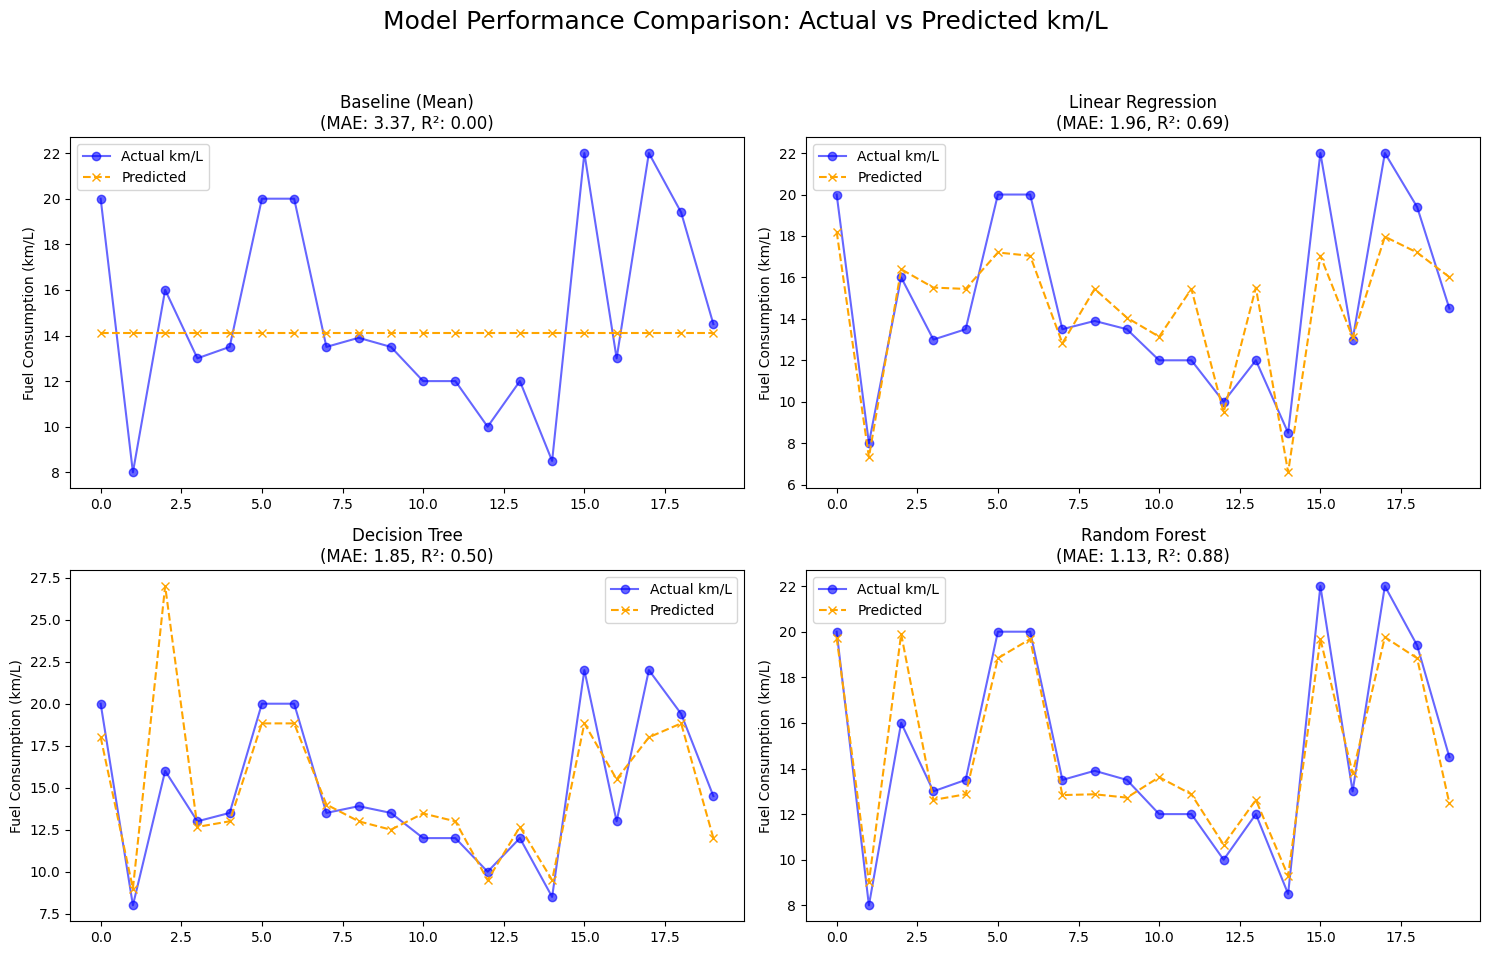

In [ ]:
models = {
    'Baseline (Mean)':   np.full_like(y_test, fill_value=y_train.mean()),
    'Linear Regression': LinearRegression().fit(X_train, y_train).predict(X_test),
    'Decision Tree':     DecisionTreeRegressor(random_state=42).fit(X_train, y_train).predict(X_test),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train).predict(X_test)
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Performance Comparison: Actual vs Predicted km/L', fontsize=18)
axes = axes.flatten()

for i, (name, pred) in enumerate(models.items()):
    ax = axes[i]
    ax.plot(range(len(y_test)), y_test.values, label='Actual km/L',
            color='blue', marker='o', alpha=0.6)
    ax.plot(range(len(y_test)), pred, label='Predicted',
            color='orange', linestyle='--', marker='x')
    mae = mean_absolute_error(y_test, pred)
    r2  = r2_score(y_test, pred) if name != 'Baseline (Mean)' else 0.0
    ax.set_title(f'{name}\n(MAE: {mae:.2f}, R²: {r2:.2f})')
    ax.set_ylabel('Fuel Consumption (km/L)')
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

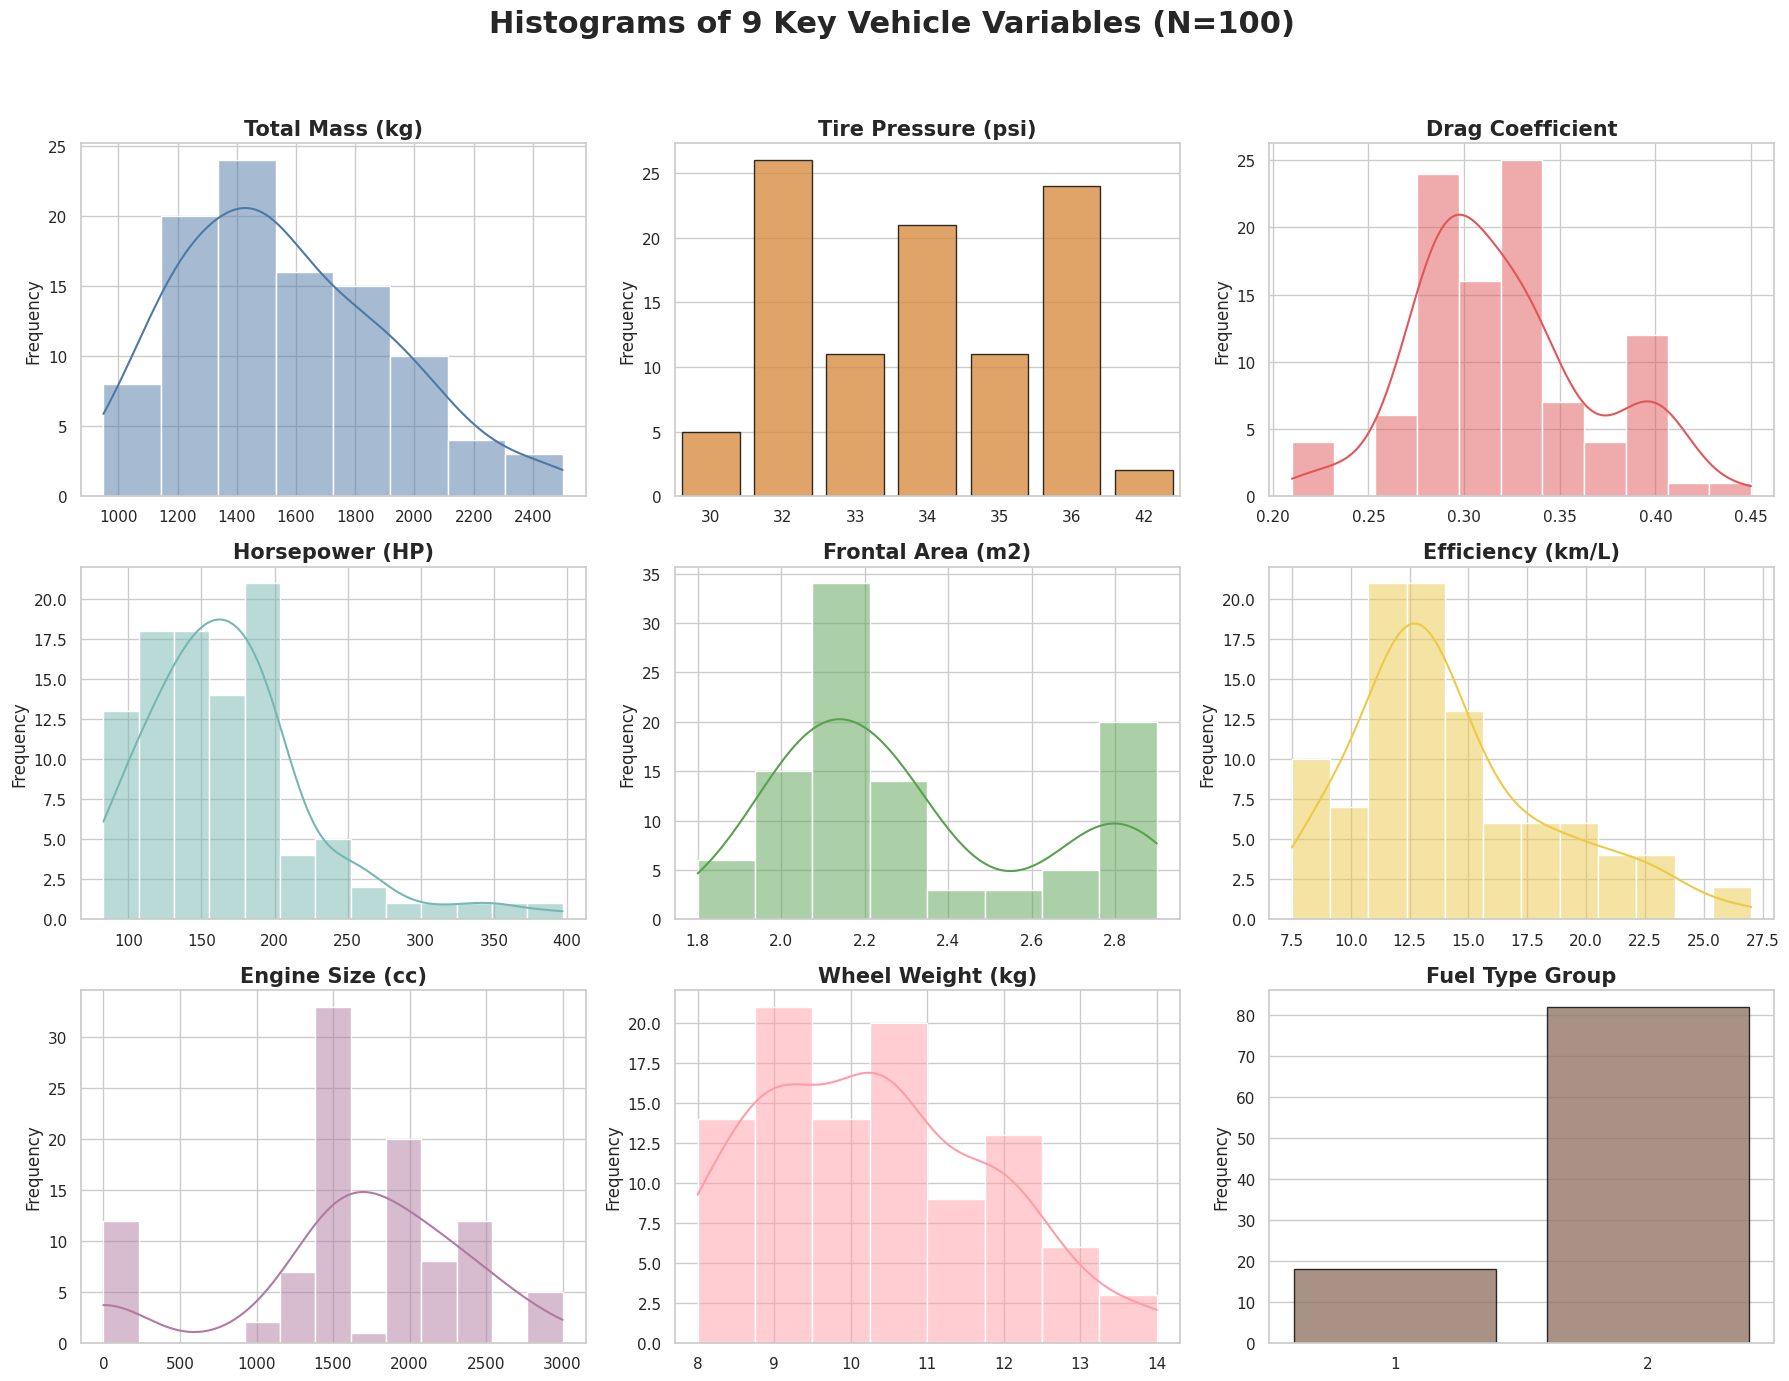

In [ ]:
plot_list = [
    ('total_mass_kg',    'Total Mass (kg)',       '#4E79A7'),
    ('tire_pressure_psi','Tire Pressure (psi)',   '#F28E2B'),
    ('drag_coefficient', 'Drag Coefficient',      '#E15759'),
    ('horsepower',       'Horsepower (HP)',        '#76B7B2'),
    ('frontal_area_m2',  'Frontal Area (m2)',      '#59A14F'),
    ('est_km_per_l',     'Efficiency (km/L)',      '#EDC948'),
    ('displacement_cc',  'Engine Size (cc)',       '#B07AA1'),
    ('mag_weight_kg',    'Wheel Weight (kg)',      '#FF9DA7'),
    ('fuel_type',        'Fuel Type Group',        '#9C755F'),
]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Histograms of 9 Key Vehicle Variables (N=100)', fontsize=22, fontweight='bold', y=0.95)

for i, (col, title, color) in enumerate(plot_list):
    ax = axes[i//3, i%3]
    if df[col].nunique() < 10:
        sns.countplot(x=df[col], ax=ax, color=color, edgecolor='black', alpha=0.8)
    else:
        sns.histplot(df[col], kde=True, ax=ax, color=color, edgecolor='white')
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

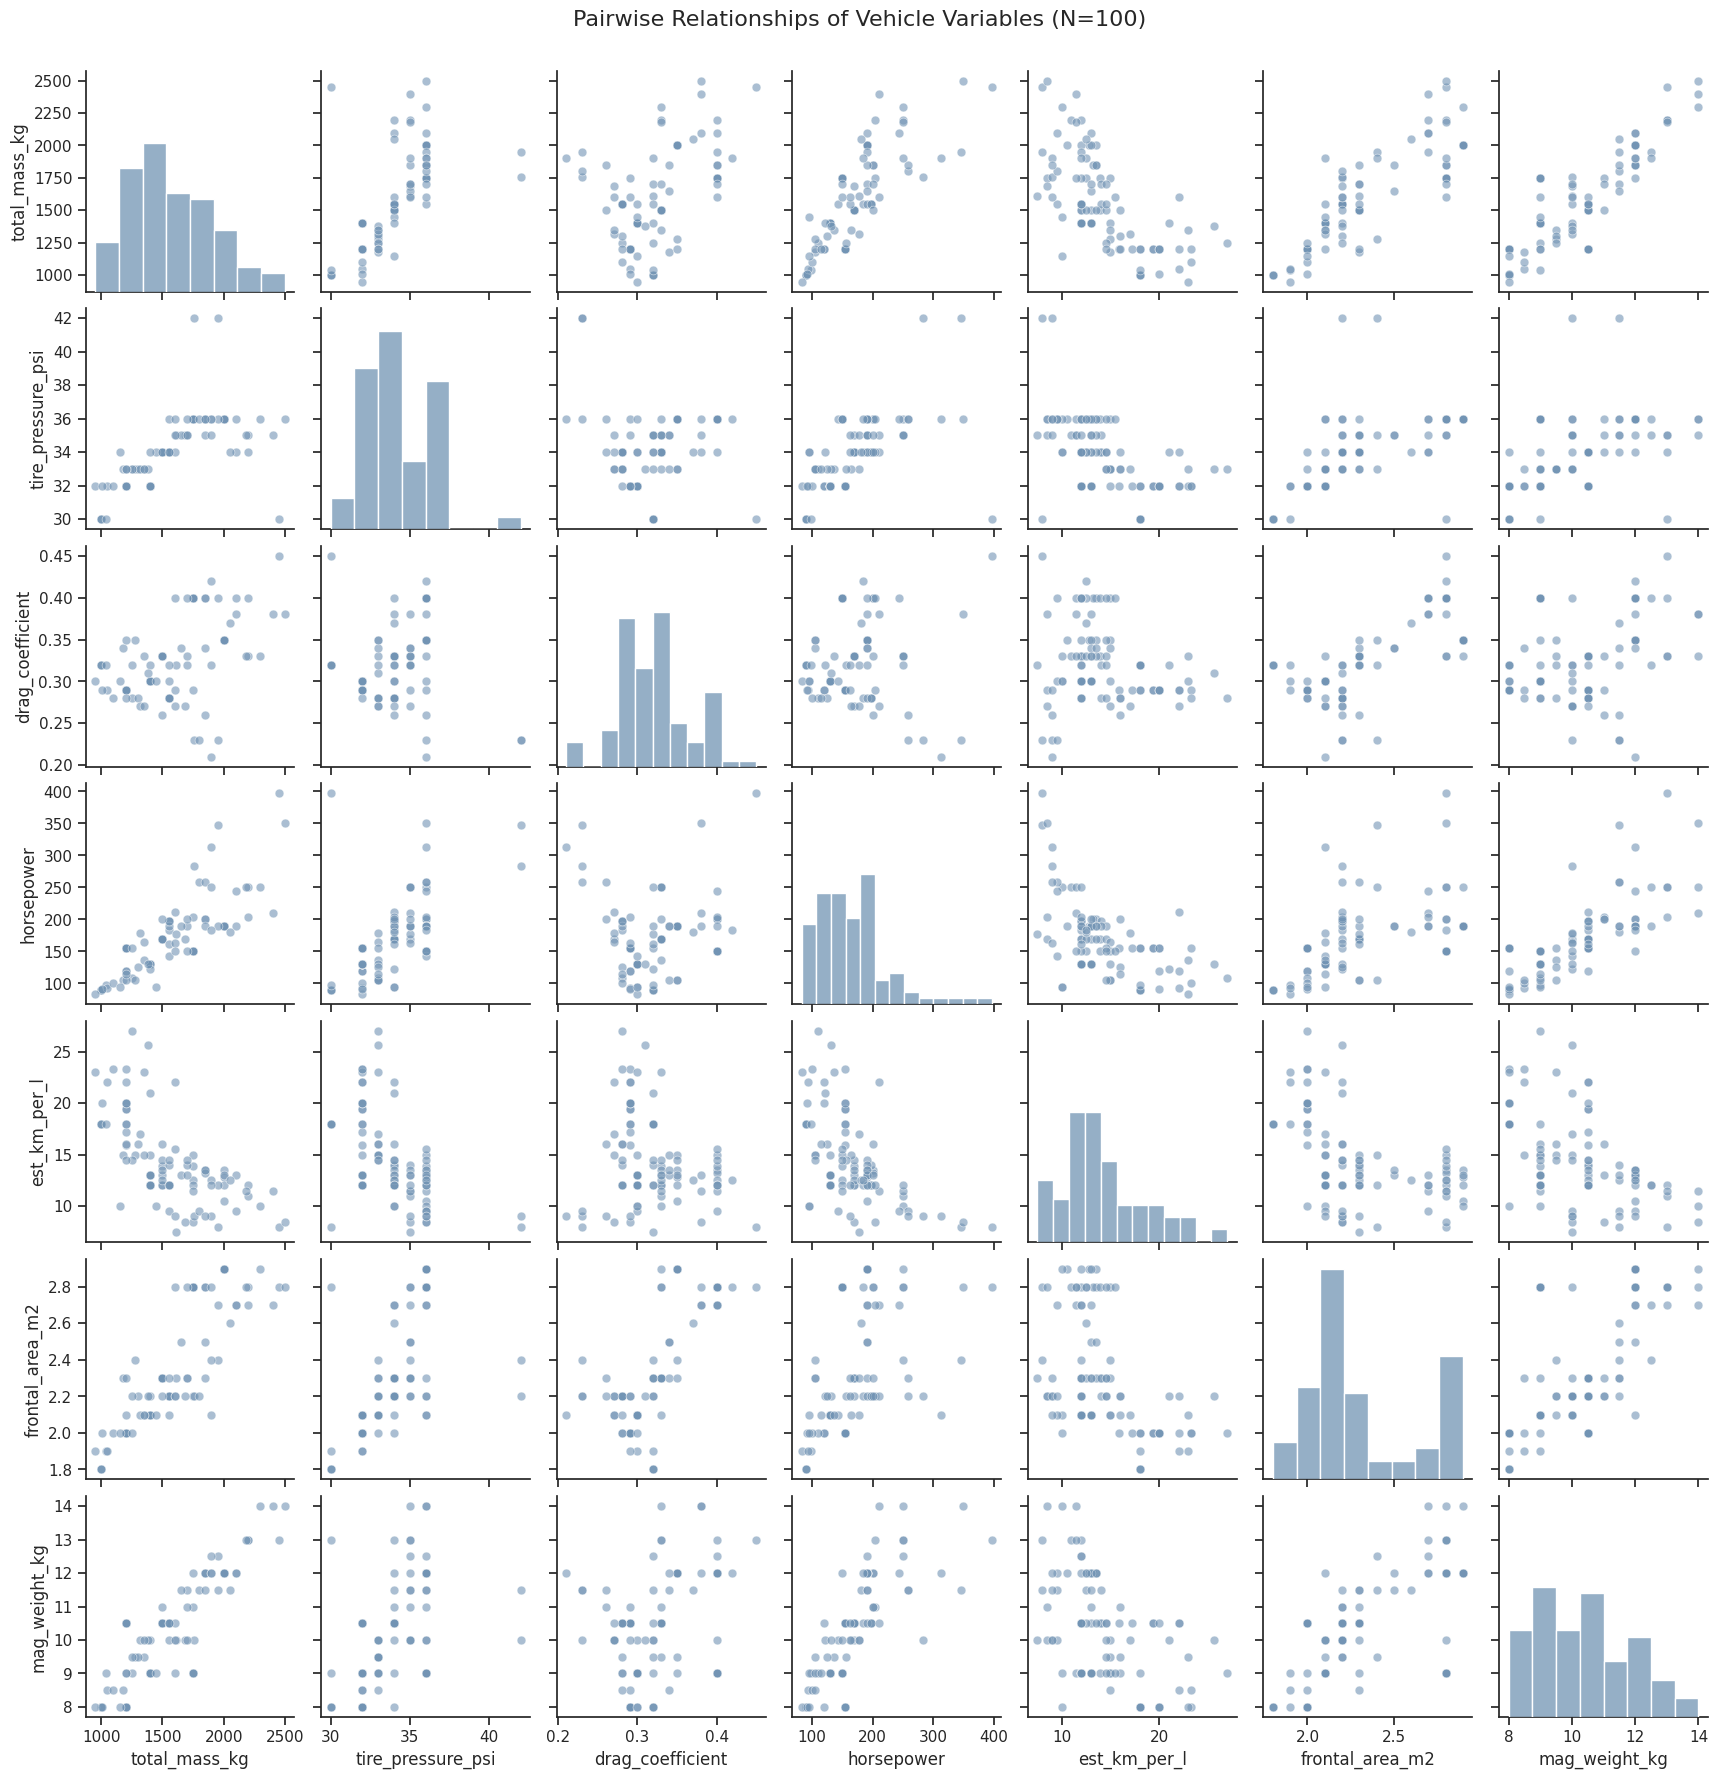

In [ ]:
selected_cols = [
    'total_mass_kg', 'tire_pressure_psi', 'drag_coefficient',
    'horsepower', 'est_km_per_l', 'frontal_area_m2', 'mag_weight_kg'
]

sns.set_theme(style="ticks", rc={"axes.spines.right": False, "axes.spines.top": False})

g = sns.pairplot(
    df[selected_cols],
    diag_kind='hist',
    plot_kws={'alpha': 0.6, 's': 40, 'color': '#7294B4', 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'color': '#7294B4', 'edgecolor': 'white'}
)
g.fig.suptitle('Pairwise Relationships of Vehicle Variables (N=100)', y=1.02, fontsize=16)
plt.show()

In [ ]:
plot_cols = [
    'total_mass_kg', 'tire_pressure_psi', 'drag_coefficient',
    'horsepower', 'frontal_area_m2', 'est_km_per_l', 'fuel_type'
]

sns.set_theme(style="ticks")

g = sns.pairplot(
    df[plot_cols],
    hue='fuel_type',
    diag_kind='kde',
    palette='viridis',
    plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'white'},
    corner=False
)
g.fig.suptitle('Multivariate Analysis Classified by Fuel Type', y=1.02, fontsize=16)
plt.show()